need 64GB memory

In [4]:
import scanpy as sc
import pickle

tmp_dir = "/root/PyCode/scRNA/CellFateExplorer/notebook/tmp"
via_object = pickle.load(open(f"{tmp_dir}/via_core.pkl", "rb"))
adata = sc.read(f"{tmp_dir}/adata_new.h5ad")
via_object 

: 

In [3]:
f"{tmp_dir}/adatda_new.h5ad"

'/root/PyCode/scRNA/CellFateExplorer/notebook/tmp/adatda_new.h5ad'

In [ ]:
from cafe.method.function.cf_stavia import extract_trajectory_dict

trajectory_dict = extract_trajectory_dict(adata, via_object)
trajectory_dict

In [7]:
import pandas as pd

cluster_list = fadata.obs["stage"].cat.categories.tolist()
milestone_network = pd.DataFrame(
    data = list(zip(cluster_list[:-1], cluster_list[1:])),
    columns=["from", "to"],
)
fadata.add_trajectory_mannually(
    milestone_network=milestone_network,
    cluster_key="stage",
)

DEBUG    |- FateAnnData add_trajectory                                                                                                                                                                  
DEBUG    |- generate milestone color from palette.                                                                                                                                                      


DEBUG    |- Generating stack plot for clusters in 'fadata.obs[celltype]'...                                                                                                                             
DEBUG    |- calculating new pseudotime                                                                                                                                                                  
DEBUG    |- save pseudotime to trajectory dict with key: `pseudotime_from_E6.5`                                                                                                                         
INFO     |- Preparing FateAnnData for stream plotting (model: ref)                                                                                                                                      
DEBUG    |- Stream tree built with 9 nodes, 8 edges                                                                                                                                                 

[<Figure size 1000x600 with 1 Axes>]

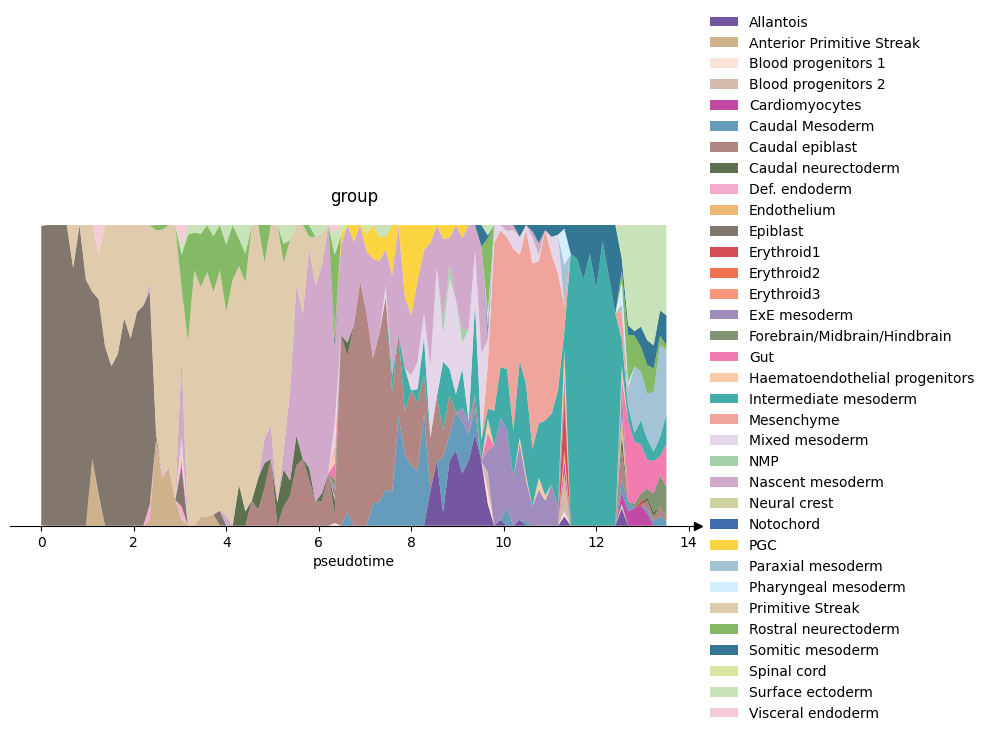

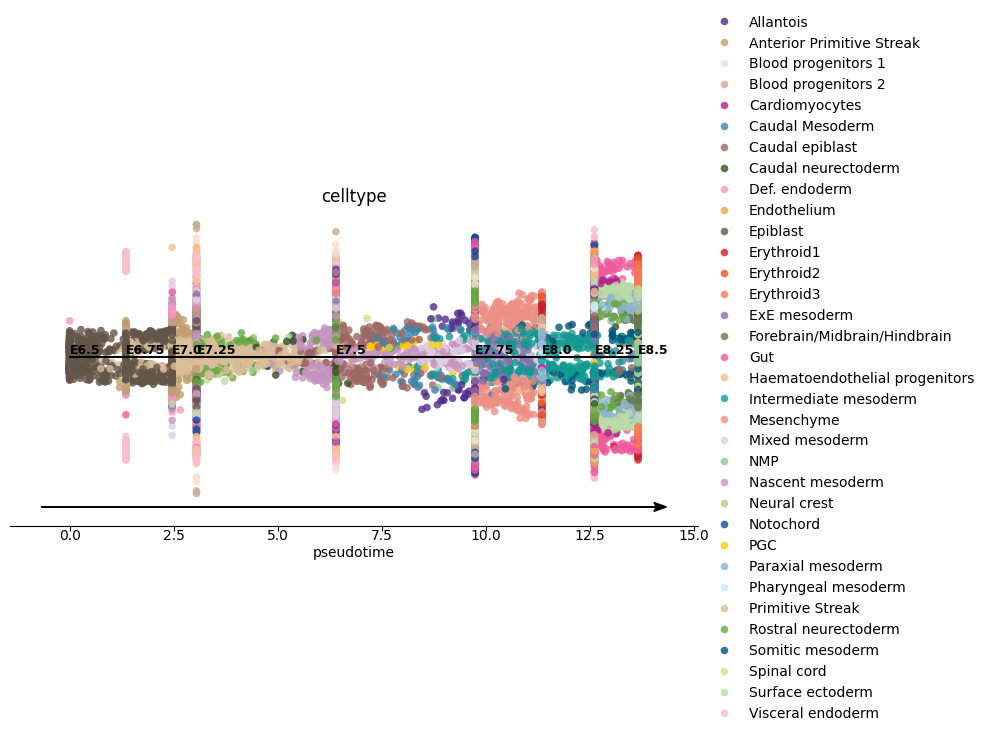

In [8]:
fadata.add_prior_information(start_milestone="E6.5")
cafe.plot.plot_stack(fadata, cluster="celltype")
cafe.plot.plot_stream(fadata, color="celltype")

DEBUG    |- Generating stack plot for clusters in 'fadata.obs[celltype]'...                                                                                                                             


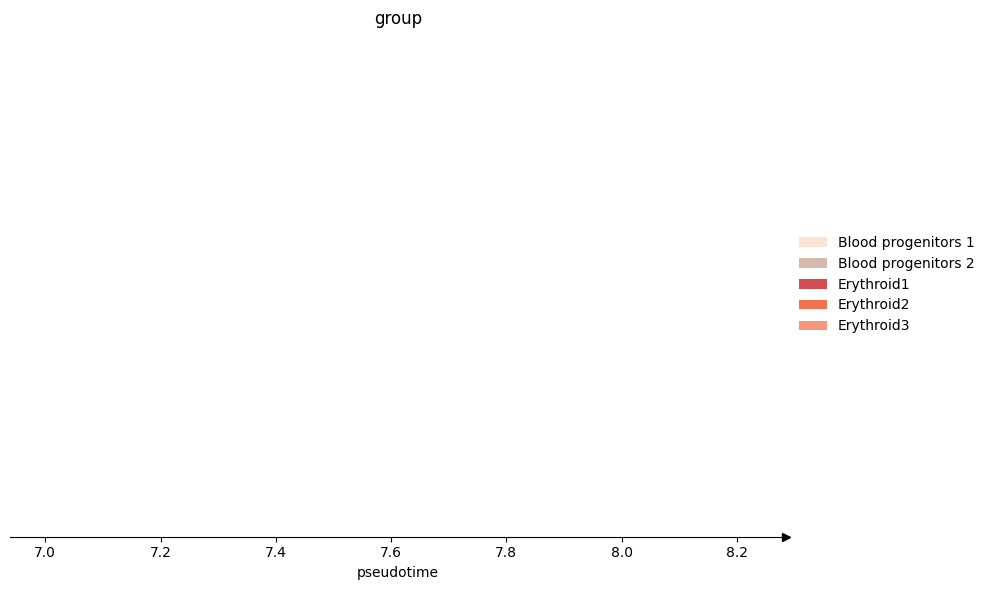

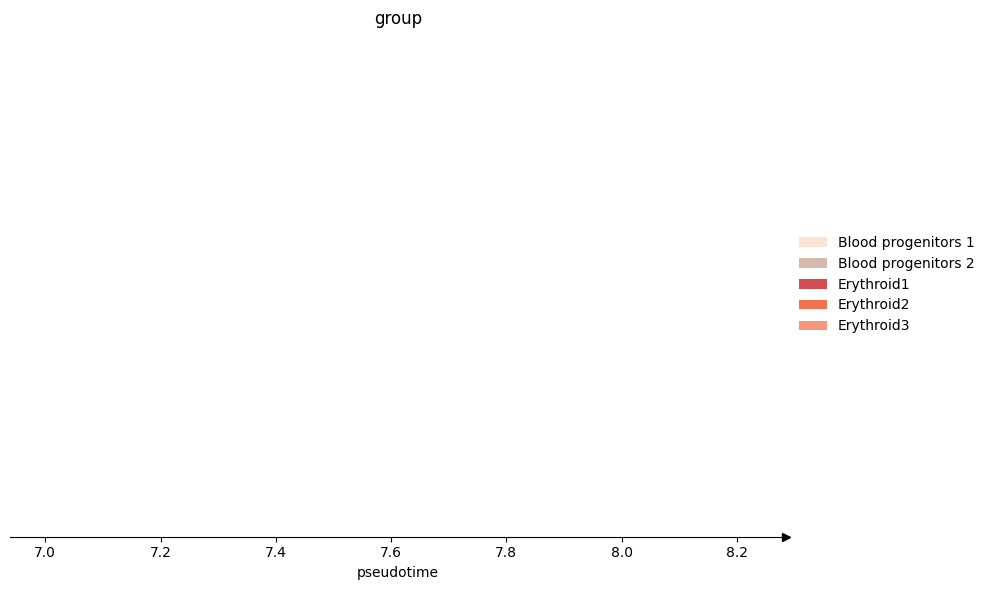

In [ ]:
# 直接设置pseudotime会有bug
# aim_cluster_list = ["Blood progenitors 1", "Blood progenitors 2", "Erythroid1", "Erythroid2", "Erythroid3"]
# tmp_adata = adata[adata.obs["celltype"].apply(lambda x: x in aim_cluster_list)]
# tmp_adata.obs["pseudotime"] = tmp_adata.obs["stage"].apply(lambda x: float(x[1:])).astype("float")
# cafe.plot.plot_stack(tmp_adata, pseudotime_key="pseudotime", cluster="celltype", n_bins=50)